In [ ]:
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
from brian2 import StateMonitor, ms

from sango import EdgeGroup, Network, NodeGroup
from sango.backend import SimBrian
from sango.model import Neuron, Synapse

# Izhikevich 2003: Simple Model of Spiking Neurons Sango Implementation

This notebook implements the Izhikevich neuron along with the 800/200 random excitatory and inhibitory network found in Figure 3 of:

```bibtex
@article{izhikevich2003simple,
  title={Simple model of spiking neurons},
  author={Izhikevich, Eugene M},
  journal={IEEE Transactions on neural networks},
  volume={14},
  number={6},
  pages={1569--1572},
  year={2003},
  publisher={IEEE}
}
```

https://www.izhikevich.org/publications/spikes.pdf

The results should match the Brian2 example found at:

https://brian2.readthedocs.io/en/stable/examples/frompapers.Izhikevich_2003.html

# Sango Brian2 Backend Model Registry Definition

In [ ]:
# Neuron Model and Synapse
model_registry = {
    'Izh': {
        'graph_type': 'neuron',
        'model_eqs': """
            dv/dt = (0.04*v**2 + 5*v + 140 - u + I + I_noise)/ms : 1
            du/dt = (a*(b*v - u))/ms  : 1
            I_noise : 1
            I : 1
            a : 1
            b : 1
            c : 1
            d : 1
            vth: 1
            randc: 1
        """,
        'refractory': '0*ms',
        'method': 'euler',
        'threshold': 'v>=vth',
        'reset': 'v=c; u+=d',
        'events': {},
        'run_regularly': [
            {'eqs': 'I_noise = randc*randn()', 'when': 'start'},
            {'eqs': 'I = 0', 'when': 'after_groups'},
        ],
        'state': {
            'a': {'dsl': 'a', 'default': 0.0},
            'b': {'dsl': 'b', 'default': 0.0},
            'c': {'dsl': 'c', 'default': 0.0},
            'd': {'dsl': 'd', 'default': 0.0},
            'v': {'dsl': 'v', 'default': 0.0},
            'u': {'dsl': 'u', 'default': 0.0},
            'I': {'dsl': 'I', 'default': 0.0},
            'vth': {'dsl': 'vth', 'default': 0.0},
            'randc': {'dsl': 'randc', 'default': 0.0},
        },
    },
    'IzhSynapse': {
        'graph_type': 'synapse',
        'model_eqs': 'weight : 1',
        'on_pre': 'I_post += weight',
        'state': {
            'delay': {'dsl': 'delay', 'default': 0.0, 'unit': 'ms'},
            'weight': {'dsl': 'weight', 'default': 1.0},
        },
    },
}


# Sango Dataclasses for Defining Neuron and Synapse Parameters

The following dataclasses define the Izhikevich neuron and synapse parameters. These will be used in the backend to map the parameters to the Brian2 neurons and synapses implemented in `sango.backend.brian.registry` or above.

In [3]:
@dataclass
class Izhikevich(Neuron):
    """Izhikevich neuron parameters for equations:

    dv/dt = (0.04*v**2 + 5*v + 140 - u + I + I_noise)/ms : 1
    du/dt = (a*(b*v - u))/ms  : 1
    """

    model: str = 'Izh'
    a: float = 0.0
    b: float = 0.0
    c: float = 0.0
    d: float = 0.0
    vth: float = 0.0
    v: float = 0.0
    u: float = 0.0
    # External current/bias
    I: float = 0.0
    # Used in I_noise = randc*randn() run_regularly and added in dv/dt
    randc: float = 0.0


@dataclass
class IzhikevichSynapse(Synapse):
    """Izhikevich synapse parameters.

    on_pre: I_post += weight
    """

    model: str = 'IzhSynapse'
    weight: float = 0.0
    delay: float = 0.0

# Helper Functions

This is a helper function to map a global synapse adjacency matrix that contains distinct indices for every neuron to relative per neuron group indices. Sango's NodeGroups use relative indices and do not require indices between groups to be disjoint.

In [4]:
def global_to_relative_idx(adj: np.ndarray, group_sizes: list) -> dict:
    """Takes in an adjacency matrix that describes the edges between all nodes
    in a network comprised of multiple NodeGroups. Uses the group sizes to infer
    how to remap global node indices to local group indices.

    For example, if we have N=2 NodeGroups of size S and T the global
    adjacency matrix would be (S+T)x(S+T) with the nodes indexed from zero to
    (S+T-1). The function takes this matrix along with the group sizes and
    outputs a dictionary of the form:

    Example of output dictionary:
        result = {
            (0, 0): {
                'edges': [(0, 1), (1, 3), ...],
                'weights': [3.0, -5.0, ...]
            },
            (0, 1): {
                'edges': [...],
                'weights': [...]
            }
            ...
        }

    Here the keys (0, 0) and (0, 1) indicate which NodeGroups are being
    connected using edges. (0, 0) contains all edges and corresponding weights
    connecting Node Group 0's nodes to nodes in the same NodeGroup (i.e. 0).
    (0, 1) contains all edges and weights that go from NodeGroup 0 to NodeGroup
    1. The dictionary contains all N^2 combinations of NodeGroups.

    Each edge is represented as a tuple (source, target) and there is one weight
    for each edge tuple in the edges list.

    This function is useful when you want to have nodes of different types or
    parameters in a network, but represent their connections using a single
    connection adjacency matrix. As long as the distinct node indices are
    contiguous, this function works.

    :param adj: The global node adjacency matrix
    :type adj: np.ndarray
    :param group_sizes: A list of NodeGroup sizes represented in the adjacency
        matrix
    :type group_sizes: list
    :raises ValueError: Mismatched adjacency matrix shape vs. sum of group sizes
    :return: A dictionary with len(group_sizes)^2 keys mapping to a list of
        directed edges defined as tuples and a list of weights that
        correspond to the edges.
    :rtype: dict
    """
    # Ensure matrix is a numpy array
    adj = np.asarray(adj)
    # Cast to list
    group_sizes = list(group_sizes)

    # Get the total nodes across the groups
    total_nodes = sum(group_sizes)

    # Sanity check that the adjacency matrix is compatible with the node
    # group sizes
    if adj.shape != (total_nodes, total_nodes):
        raise ValueError(
            f'Expected adj shape {(total_nodes, total_nodes)}, '
            f'but got {adj.shape}'
        )

    # group_offsets[g] gives the starting global index of group g
    group_offsets = np.cumsum([0] + group_sizes)

    result = {}

    num_groups = len(group_sizes)

    for source_group in range(num_groups):
        source_start = group_offsets[source_group]
        source_end = group_offsets[source_group + 1]

        for target_group in range(num_groups):
            target_start = group_offsets[target_group]
            target_end = group_offsets[target_group + 1]

            # Because adj[target, source]
            # block = adj[target_start:target_end, source_start:source_end]
            block = adj[target_start:target_end, source_start:source_end]

            # np.where returns row indices first, column indices second.
            # Here:
            #   row    = target_relative_idx
            #   column = source_relative_idx
            target_rel_idx, source_rel_idx = np.where(block != 0)

            weights = block[target_rel_idx, source_rel_idx]

            edges = list(zip(source_rel_idx.tolist(), target_rel_idx.tolist()))

            result[(source_group, target_group)] = {
                'edges': edges,
                'weights': weights.tolist(),
            }

    return result

# Izhikevich Sango Network Definition

In [5]:
class Izh2003(Network):
    """Implements the network implemented in Izhikevich 2003 paper:

    Izhikevich, Eugene M. "Simple model of spiking Neurons."
    IEEE Transactions on neural networks 14.6 (2003): 1569-1572.
    """

    def __init__(self, num_exc: int = 800, num_inh: int = 200) -> None:
        """Network constructor for reproducing the Figure 3 in the 2003 paper.

        :param num_exc: Number of excitatory neurons, defaults to 800
        :type num_exc: int, optional
        :param num_inh: Number of inhibitory neurons, defaults to 200
        :type num_inh: int, optional
        """
        super().__init__()
        self.num_exc = num_exc
        self.num_inh = num_inh
        self.total_n = self.num_exc + self.num_inh

    def build(self) -> None:
        """Builds up the 800 excitatory and 200 inhibitory neurons and connects
        them. See the paper or Brian2 example for more detail on the parameters.
        """
        # Random initialization
        self.re = np.random.uniform(size=self.num_exc)
        self.ri = np.random.uniform(size=self.num_inh)
        # Setup excitatory node group w/ parameters per paper
        self.exc = NodeGroup(
            Izhikevich(),
            size=self.num_exc,
            a=0.02 * np.ones(self.num_exc, dtype=np.float64),
            b=0.2 * np.ones(self.num_exc, dtype=np.float64),
            c=-65.0 + 15.0 * self.re**2,
            d=8.0 - 6.0 * self.re**2,
            v=-65.0 * np.ones(self.num_exc, dtype=np.float64),
            u=0.2 * -65.0,
            randc=5.0,
        )
        # Setup inhibitory node group w/ parameters per paper
        self.inh = NodeGroup(
            Izhikevich(),
            size=self.num_inh,
            a=0.02 + 0.08 * self.ri,
            b=0.25 - 0.05 * self.ri,
            c=-65.0 * np.ones(self.num_inh, dtype=np.float64),
            d=2.0 * np.ones(self.num_inh, dtype=np.float64),
            v=-65.0 * np.ones(self.num_inh, dtype=np.float64),
            u=(0.25 - 0.05 * self.ri) * -65.0,  # b * v
            randc=2.0,
        )

        # Setup synapses
        # 1000x800,
        self.s_exc = 0.5 * np.random.uniform(size=(self.total_n, self.num_exc))
        # 1000x200
        self.s_inh = -np.random.uniform(size=(self.total_n, self.num_inh))

        # 1000x(800+200)
        global_synapses = np.hstack([self.s_exc, self.s_inh])

        # Indices are relative to NodeGroups in Sango. The paper sets up
        # synapses with global indexing from 0 to 999.
        # Thus we need to translate global indices to NodeGroup relative ones.
        relative_synapses = global_to_relative_idx(
            global_synapses, [self.num_exc, self.num_inh]
        )

        # Setup synapses (i.e. EdgeGroups in Sango) between the two NodeGroups
        self.synapses_exc = EdgeGroup(
            self.exc,
            self.exc,
            IzhikevichSynapse(),
            edges=relative_synapses[(0, 0)]['edges'],
            weight=relative_synapses[(0, 0)]['weights'],
        )  # Internal to exc group
        self.synapses_inh = EdgeGroup(
            self.inh,
            self.inh,
            IzhikevichSynapse(),
            edges=relative_synapses[(1, 1)]['edges'],
            weight=relative_synapses[(1, 1)]['weights'],
        )  # Internal to inh group
        self.synapses_ei = EdgeGroup(
            self.exc,
            self.inh,
            IzhikevichSynapse(),
            edges=relative_synapses[(0, 1)]['edges'],
            weight=relative_synapses[(0, 1)]['weights'],
        )  # exc to inh
        self.synapses_ie = EdgeGroup(
            self.inh,
            self.exc,
            IzhikevichSynapse(),
            edges=relative_synapses[(1, 0)]['edges'],
            weight=relative_synapses[(1, 0)]['weights'],
        )  # inh to exc

# Experiments

In [6]:
# Initialize the network parameters
TIMESTEPS = 1000
NUM_EXC = 800
NUM_INH = 200
net = Izh2003(NUM_EXC, NUM_INH)
net.build()

info: flattening network topology


In [7]:
# Print Sango's network representation
print(net)

(node) exc
(node) inh
(edge) synapses_exc: (node) exc -> (node) exc
(edge) synapses_inh: (node) inh -> (node) inh
(edge) synapses_ei: (node) exc -> (node) inh
(edge) synapses_ie: (node) inh -> (node) exc


In [8]:
# Build the network structure i.e. neuron groups and synapses
brian_sim = SimBrian(net)
# Update the Brian2 Registry with our Neuron and Synapse definitions
brian_sim.model_registry.update(model_registry)
# Generate the Brian2 network
brian_sim.compile()
# Add state monitors manually until Sango supports them
group = brian_sim.neuron_groups['Izh']
state_monitor_exc = StateMonitor(group, 'v', record=0, when='after_thresholds')
# Add the state monitor to the Brian2 network objects
brian_sim.brian_net.add(state_monitor_exc)

In [9]:
# Run the simulation
brian_sim.run(TIMESTEPS)

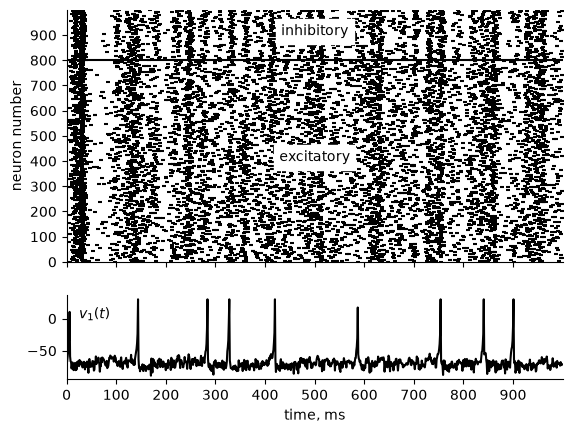

In [10]:
# Plot resulting raster plot and a single neuron's membrane potential dynamics
# using Brian2's example code:
# https://brian2.readthedocs.io/en/stable/examples/frompapers.Izhikevich_2003.html

# Convert to Brian units
tfinal = TIMESTEPS * ms

# State monitors
spikemon = brian_sim.spike_monitors['Izh']
statemon = state_monitor_exc
N = NUM_EXC + NUM_INH

_, (ax, ax_voltage) = plt.subplots(
    2, 1, sharex=True, gridspec_kw={'height_ratios': (3, 1)}
)

ax.scatter(spikemon.t / ms, spikemon.i[:], marker='_', color='k', s=10)
ax.set_xlim(0, tfinal / ms)
ax.set_ylim(0, N)
ax.set_ylabel('neuron number')
ax.set_yticks(np.arange(0, N, 100))
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.axhline(net.num_exc, color='k')
ax.text(500, 900, 'inhibitory', backgroundcolor='w', color='k', ha='center')
ax.text(500, 400, 'excitatory', backgroundcolor='w', color='k', ha='center')

ax_voltage.plot(statemon.t / ms, np.clip(statemon.v[0], -np.inf, 30), color='k')
ax_voltage.text(25, 0, '$v_1(t)$')
ax_voltage.set_xticks(np.arange(0, tfinal / ms, 100))
ax_voltage.spines['right'].set_visible(False)
ax_voltage.spines['top'].set_visible(False)
ax_voltage.set_xlabel('time, ms')

plt.show()